In [6]:

%load_ext autoreload
%autoreload 2

import numpy as np
from mpc_utils import save_results, mpc_results_dir
from param_loader import METANET_Params
from simulation_utils import run_metanet_sim

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
num_calibrated_segments = 15
horizon = 360

lanes = np.array([4 if i < num_calibrated_segments - 5 else 2 for i in range(num_calibrated_segments)])

downstream_density = np.full(horizon, 0)
data_inflow = np.array([5500 if i in range(20, 20 + 90) else 4000 for i in range(horizon)])

In [178]:
# Generate Ground truth parameters
valid_parameter_bounds = {
    "tau": (10.0 / 3600, 60.0 / 3600),
    "K": (5, 60),
    "eta_high": (10, 90),
    "p_crit": (15.0, 100.0),
    "v_free": (70, 140),
    "a": (0.5, 5),
}
static_syn = METANET_Params(path=None, num_segments=15).get_params()
static_syn["num_lanes"] = lanes
variance = 0.3
rain= True

if rain == False:
    root_path = f"cdc_results/synthetic_data/gt_var{variance}"

    # For t in the horizon, add some perturbation to the nominal params, add lanes to the dictionary, and save the results to save_path
    for t in range(horizon):
        perturbed_params = {}
        for param_name, param_array in static_syn.items():
            if param_name not in valid_parameter_bounds:
                perturbed_params[param_name] = param_array
            else:
                # clip parameters to be within the valid bounds after adding noise
                noise = np.random.normal(0, variance * np.abs(param_array), seed=7)
                perturbed_params[param_name] = param_array + noise
                perturbed_params[param_name] = np.clip(perturbed_params[param_name], *valid_parameter_bounds[param_name])

        save_results(perturbed_params, mpc_results_dir(root_path, control_horizon=1) + f"/params_{t+1}", from_param_loader=True)
else:
    root_path = f"cdc_results/synthetic_data_rain/gt_var{variance}"

    # --- time step split ---
    # assumes T_step = 10s, so 45 min = 270 steps, 15 min = 90 steps
    T_step_seconds = 10
    t_ramp_end     = int(45 * 60 / T_step_seconds)  # 270 steps — end of ramp-up
    t_flat_end     = int(60 * 60 / T_step_seconds)  # 360 steps — end of horizon

    assert t_ramp_end + (t_flat_end - t_ramp_end) == horizon, \
        f"Horizon mismatch: expected {horizon} steps, got {t_flat_end}"

    # --- build v_free trajectory ---
    # starts at v_free_initial * (1 - variance), ramps up to 120 over 45 min,
    # then holds at 120 for the final 15 min
    v_free_initial = static_syn['v_free'].copy()             # shape (N,)
    v_free_start   = v_free_initial * (1 - variance)         # reduced starting value
    v_free_peak    = np.full_like(v_free_initial, 120.0)     # target: 120 km/h

    # ramp-up phase: linear from v_free_start to 120 over first 45 min
    ramp   = np.linspace(v_free_start, v_free_peak, t_ramp_end)   # shape (270, N)

    # flat phase: hold at 120 for final 15 min
    flat   = np.tile(v_free_peak, (t_flat_end - t_ramp_end, 1))   # shape (90, N)

    v_free_steps = np.vstack([ramp, flat])                         # shape (360, N)
    v_free_steps = np.clip(
        v_free_steps,
        *valid_parameter_bounds['v_free']
    )

    # --- generate and save params for each time step ---
    for t in range(horizon):
        perturbed_params = {}
        for param_name, param_array in static_syn.items():
            if param_name == 'v_free':
                perturbed_params[param_name] = v_free_steps[t]
            else:
                perturbed_params[param_name] = param_array

        save_results(
            perturbed_params,
            mpc_results_dir(root_path, control_horizon=1) + f"/params_{t+1}",
            from_param_loader=True
        )



In [179]:
# Simulate perturbed params
sim_var = variance
dynamic_syn = METANET_Params(path=f"cdc_results/synthetic_data_rain/gt_var{sim_var}", control_h=1, num_timesteps=horizon, num_segments=num_calibrated_segments).get_params()

T= 10/3600
l = 0.4

init_traffic_state = (np.array([1000 / 90 for i in range(num_calibrated_segments)]), np.array([90 for i in range(num_calibrated_segments)]), 4000, 0)
dyn_rho_sim, dyn_v_sim, _, tts_sim = run_metanet_sim(
    T, 
    l, 
    init_traffic_state,
    data_inflow,
    downstream_density,
    dynamic_syn,
    vsl_speeds=None,
    lanes={i: lanes[i] for i in range(num_calibrated_segments)},
    plotting=True,
    real_data=True
)

dyn_rho_sim = dyn_rho_sim[0:-1, :]
dyn_v_sim = dyn_v_sim[0:-1, :]

In [180]:
stat_rho_sim, stat_v_sim, _, tts_sim = run_metanet_sim(
    T, 
    l, 
    init_traffic_state,
    data_inflow,
    downstream_density,
    static_syn,
    vsl_speeds=None,
    lanes={i: lanes[i] for i in range(num_calibrated_segments)},
    plotting=True,
    real_data=True
)

stat_rho_sim = stat_rho_sim[0:-1, :]
stat_v_sim = stat_v_sim[0:-1, :]

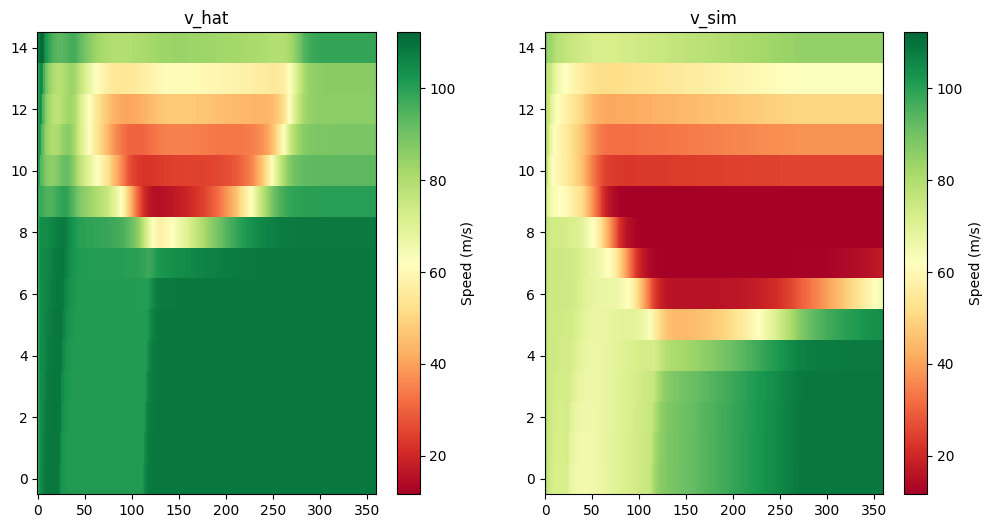

In [181]:
# Plot v hat and v sim side by side as a heatmap
import matplotlib.pyplot as plt
vmin = min(np.min(stat_v_sim), np.min(dyn_v_sim))
vmax = max(np.max(stat_v_sim), np.max(dyn_v_sim))
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("v_hat")
plt.imshow(stat_v_sim.T, aspect='auto', cmap='RdYlGn', origin='lower', interpolation="none", vmin=vmin, vmax=vmax)
plt.colorbar(label='Speed (m/s)')
plt.subplot(1, 2, 2)
plt.title("v_sim")
plt.imshow(dyn_v_sim.T, aspect='auto', cmap='RdYlGn', origin='lower', interpolation="none", vmin=vmin, vmax=vmax)
plt.colorbar(label='Speed (m/s)')
plt.show()

In [182]:
# Save q_sim and v_sim in data folder

rho_sim_calib = dyn_rho_sim * lanes
v_sim_calib = dyn_v_sim
q_sim_calib = rho_sim_calib * v_sim_calib
np.save(f"data/synthetic_dynamic_rain/q_synthetic_var{variance}.npy", q_sim_calib)
np.save(f"data/synthetic_dynamic_rain/p_synthetic_var{variance}.npy", rho_sim_calib)

In [185]:
import numpy as np
from pathlib import Path

# --- Config ---
variances = [0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]  # replace with your actual list
data_dir = Path("data/synthetic_dynamic_rain")

def load_and_combine(variance):
    """Load density (rho) and flow (q) arrays and concatenate along the channel axis."""
    q   = np.load(f"data/synthetic_dynamic_rain/q_synthetic_var{variance}.npy")    # shape: (T, ..., C_q)
    rho = np.load(f"data/synthetic_dynamic_rain/p_synthetic_var{variance}.npy")  # shape: (T, ..., C_rho)

    v = q / rho  # compute speed (v = q / rho), shape: (T, ..., C_q) assuming C_q == C_rho

    # Concatenate along the last (channel) axis → shape: (T, ..., C_q + C_rho)
    x = np.concatenate([v, rho/lanes], axis=-1)

    return x

def compute_gt_variance(x: np.ndarray) -> float:
    """
    Compute (1/T) * sum_{t=0}^{T-1} ||x_t - x_bar||^2
    where x has shape (T, ...) and x_bar is the temporal mean.
    """
    T = x.shape[0]
    x_bar = x.mean(axis=0, keepdims=True)          # shape: (1, ...)
    diff  = x - x_bar                              # shape: (T, ...)
    sq_norms = (diff ** 2).reshape(T, -1).sum(-1)  # ||x_t - x_bar||^2 per timestep
    return sq_norms.mean()                          # divide by T

# --- Main loop ---
results = {}

for var in variances:
    x = load_and_combine(var)
    gt_var = compute_gt_variance(x)
    results[var] = gt_var
    print(f"variance={var:>5} | shape={x.shape} | GT variance = {gt_var:.6f}")

variance=    0 | shape=(360, 30) | GT variance = 5266.204097
variance= 0.05 | shape=(360, 30) | GT variance = 5023.907525
variance=  0.1 | shape=(360, 30) | GT variance = 4643.747003
variance= 0.15 | shape=(360, 30) | GT variance = 5180.845556
variance=  0.2 | shape=(360, 30) | GT variance = 5715.741457
variance= 0.25 | shape=(360, 30) | GT variance = 6318.170761
variance=  0.3 | shape=(360, 30) | GT variance = 6833.536733
